# KLA - Baseline NAFNet Training

Degraded Input -> Normalisation -> Degradataion Encoder -> NAFNet -> Charbonnier loss

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.4'
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
import sys
import time
import dataclasses
from pathlib import Path
from typing import Callable

import jax
import jax.numpy as jnp
import numpy as np
import optax
import orbax.checkpoint as ocp
import grain
from flax import nnx

# grain's multiprocessing worker path reads absl flags; needed outside absl.app.run()
from absl import flags as _absl_flags
if not _absl_flags.FLAGS.is_parsed():
    _absl_flags.FLAGS(sys.argv[:1])

In [2]:
TRAIN_PATH = "./train/train"
TEST_PATH = "./Test_NoisyLR"

TRAIN_LR_PATH = os.path.join(TRAIN_PATH, "NoisyLR")
TEST_LR_PATH = os.path.join(TEST_PATH, "NoisyLR")
TRAIN_GT_PATH = os.path.join(TRAIN_PATH, "GT")

In [3]:
from dataloader import create_dataloader


In [4]:
EPS = 1e-6


def zscore_normalize(x: jax.Array, axis=None, eps: float = EPS) -> jax.Array:
    mean = jnp.mean(x, axis=axis, keepdims=True)
    std = jnp.std(x, axis=axis, keepdims=True)
    return (x - mean) / (std + eps)


def zscore_denormalize(x_norm: jax.Array, mean: jax.Array, std: jax.Array, eps: float = EPS) -> jax.Array:
    return x_norm * (std + eps) + mean


def asinh_normalize(x: jax.Array, axis=None, eps: float = EPS) -> jax.Array:
    median = jnp.median(x, axis=axis, keepdims=True)
    q75 = jnp.quantile(x, 0.75, axis=axis, keepdims=True)
    q25 = jnp.quantile(x, 0.25, axis=axis, keepdims=True)
    iqr = q75 - q25
    return jnp.arcsinh((x - median) / (iqr + eps))


def asinh_denormalize(x_norm: jax.Array, median: jax.Array, iqr: jax.Array, eps: float = EPS) -> jax.Array:
    return jnp.sinh(x_norm) * (iqr + eps) + median


# Registry so the train script can select strategy by name from config,
# without importing every function individually.
NORMALIZERS: dict[str, Callable[..., jax.Array]] = {
    "zscore": zscore_normalize,
    "asinh": asinh_normalize,
    "none": lambda x, **kwargs: x,
}


def get_normalizer(name: str) -> Callable[..., jax.Array]:
    if name not in NORMALIZERS:
        raise ValueError(f"Unknown normalizer '{name}'. Options: {list(NORMALIZERS)}")
    return NORMALIZERS[name]


In [5]:
# DegradationEncoder moved to model_util.py


In [6]:
# NAF Block components and model architecture moved to model_util.py


In [7]:
# asinh_normalize already defined in Cell 4 above


In [8]:
# DegradationEncoder moved to model_util.py


In [9]:
from model_util import (
    DegradationEncoder,
    SimpleGate,
    SimplifiedChannelAttention,
    FiLM,
    NAFBlock,
    PixelShuffle,
    BaselineNAFNet,
    RestorationPipeline,
)


In [10]:
def charbonnier_loss_mean(pred: jax.Array, target: jax.Array, eps: float = 1e-3) -> jax.Array:
    diff = pred - target
    return jnp.mean(jnp.sqrt(diff * diff + eps * eps))

In [11]:
def compute_bicubic_upsample(noisy: jax.Array, target_hw: tuple[int, int]) -> jax.Array:
    """Resizes the degraded input to target resolution so it aligns
    pixel-for-pixel with NAFNet's corruption-map output, enabling the
    subtraction pred = y_upsampled - corruption.
    """
    b, h, w, c = noisy.shape
    return jax.image.resize(noisy, (b, target_hw[0], target_hw[1], c), method="bicubic")


def make_train_step(normalizer_fn):
    @nnx.jit
    def train_step(model: RestorationPipeline, optimizer: nnx.Optimizer, batch: dict) -> jax.Array:
        """Executes a single training step with Charbonnier loss."""
        noisy = batch["noisy_lr"].astype(jnp.float32)
        gt = batch["gt"].astype(jnp.float32)
        x_norm = normalizer_fn(noisy, axis=(1, 2))
        y_upsampled = compute_bicubic_upsample(noisy, gt.shape[1:3])

        def loss_fn(model_ref):
            pred, _z_d = model_ref(x_norm, y_upsampled)
            return charbonnier_loss_mean(pred, gt)

        loss, grads = nnx.value_and_grad(loss_fn)(model)
        optimizer.update(model, grads)
        return loss

    return train_step


def make_val_step(normalizer_fn):
    @nnx.jit
    def val_step(model: RestorationPipeline, batch: dict) -> tuple[jax.Array, jax.Array]:
        """Executes a validation/inference step without calculating gradients."""
        noisy = batch["noisy_lr"].astype(jnp.float32)
        gt = batch["gt"].astype(jnp.float32)
        x_norm = normalizer_fn(noisy, axis=(1, 2))
        y_upsampled = compute_bicubic_upsample(noisy, gt.shape[1:3])
        pred, _z_d = model(x_norm, y_upsampled)
        loss = charbonnier_loss_mean(pred, gt)
        return loss, pred

    return val_step


def to_device(batch: dict) -> dict:
    return jax.tree.map(jax.device_put, batch)

In [ ]:
def build_checkpoint_manager(ckpt_dir, max_to_keep=5):
    options = ocp.CheckpointManagerOptions(
        max_to_keep=max_to_keep,
        save_interval_steps=1,  
        create=True,
        enable_async_checkpointing=True,
    )
    ckpt_dir = Path(ckpt_dir).resolve()
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    return ocp.CheckpointManager(str(ckpt_dir), options=options)


def save_checkpoint(manager, step, model, optimizer, epoch, train_loss):
    _, model_state = nnx.split(model)
    _, opt_state = nnx.split(optimizer)
    metadata = {"epoch": epoch, "step": step, "train_loss": float(train_loss)}

    manager.save(
        step,
        args=ocp.args.Composite(
            model_state=ocp.args.StandardSave(model_state),
            opt_state=ocp.args.StandardSave(opt_state),
            metadata=ocp.args.JsonSave(metadata),
        ),
    )


def restore_checkpoint(manager, step, model, optimizer):
    _, abstract_model_state = nnx.split(nnx.eval_shape(lambda: model))
    _, abstract_opt_state = nnx.split(nnx.eval_shape(lambda: optimizer))

    restored = manager.restore(
        step,
        args=ocp.args.Composite(
            model_state=ocp.args.StandardRestore(abstract_model_state),
            opt_state=ocp.args.StandardRestore(abstract_opt_state),
            metadata=ocp.args.JsonRestore(),
        ),
    )
    nnx.update(model, restored.model_state)
    nnx.update(optimizer, restored.opt_state)
    return dict(restored.metadata)

In [25]:
@dataclasses.dataclass
class TrainConfig:
    train_noisy_dir: str
    train_gt_dir: str
    batch_size: int = 8
    worker_count: int = 1
    seed: int = 42

    in_channels: int = 1
    out_channels: int = 1
    hidden_dim: int = 32
    num_blocks: int = 4
    upsample_scale: int = 2

    deg_hidden_dim: int = 16
    deg_embed_dim: int = 8

    normalization: str = "asinh"

    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    grad_clip_norm: float = 1.0

    num_epochs: int = 100
    steps_per_epoch: int = 200

    ckpt_dir: str = "checkpoints"
    ckpt_every_epochs: int = 5
    max_to_keep: int = 5

    log_every_steps: int = 20


cfg = TrainConfig(
    train_noisy_dir=TRAIN_LR_PATH,
    train_gt_dir=TRAIN_GT_PATH,
    batch_size=8,
    hidden_dim=32,
    num_blocks=4,
    num_epochs=100,
    steps_per_epoch=200,
    ckpt_dir="./checkpoints",
    ckpt_every_epochs=5,
)

In [26]:
rngs = nnx.Rngs(cfg.seed)
model = RestorationPipeline(
    in_channels=cfg.in_channels, out_channels=cfg.out_channels, hidden_dim=cfg.hidden_dim,
    num_blocks=cfg.num_blocks, upsample_scale=cfg.upsample_scale,
    deg_hidden_dim=cfg.deg_hidden_dim, deg_embed_dim=cfg.deg_embed_dim, rngs=rngs,
)

optimizer = nnx.Optimizer(
    model,
    optax.chain(
        optax.clip_by_global_norm(cfg.grad_clip_norm),
        optax.adamw(learning_rate=cfg.learning_rate, weight_decay=cfg.weight_decay),
    ),
    wrt=nnx.Param,
)

normalizer_fn = asinh_normalize
train_step = make_train_step(normalizer_fn)

train_loader = create_dataloader(
    cfg.train_noisy_dir, cfg.train_gt_dir,
    batch_size=cfg.batch_size, worker_count=cfg.worker_count,
    seed=cfg.seed, shuffle=True, augment=True,
)

ckpt_manager = build_checkpoint_manager(cfg.ckpt_dir, max_to_keep=cfg.max_to_keep)
print(f"[hardware] backend={jax.default_backend()} devices={jax.devices()}")

[hardware] backend=gpu devices=[CudaDevice(id=0)]


In [27]:
train_iter = iter(train_loader)
global_step = 0

for epoch in range(cfg.num_epochs):
    epoch_start = time.time()
    epoch_losses = []

    for step_in_epoch in range(cfg.steps_per_epoch):
        batch = to_device(next(train_iter))
        loss = train_step(model, optimizer, batch)
        epoch_losses.append(float(loss))
        global_step += 1

        if global_step % cfg.log_every_steps == 0:
            recent = np.mean(epoch_losses[-cfg.log_every_steps:])
            print(f"[epoch {epoch:03d} step {step_in_epoch:04d} global {global_step:06d}] train_loss={recent:.5f}")

    epoch_time = time.time() - epoch_start
    train_loss_mean = float(np.mean(epoch_losses))
    print(f"[epoch {epoch:03d}] train_loss={train_loss_mean:.5f} time={epoch_time:.1f}s")

    if (epoch + 1) % cfg.ckpt_every_epochs == 0 or epoch == cfg.num_epochs - 1:
        save_checkpoint(ckpt_manager, global_step, model, optimizer, epoch, train_loss_mean)
        print(f"[checkpoint] saved at step {global_step} (epoch {epoch})")

ckpt_manager.wait_until_finished()
ckpt_manager.close()
print("[done] training complete.")

[epoch 000 step 0019 global 000020] train_loss=0.32044
[epoch 000 step 0039 global 000040] train_loss=0.12779
[epoch 000 step 0059 global 000060] train_loss=0.06356
[epoch 000 step 0079 global 000080] train_loss=0.05611
[epoch 000 step 0099 global 000100] train_loss=0.05349
[epoch 000 step 0119 global 000120] train_loss=0.05432
[epoch 000 step 0139 global 000140] train_loss=0.05147
[epoch 000 step 0159 global 000160] train_loss=0.05045
[epoch 000 step 0179 global 000180] train_loss=0.05091
[epoch 000 step 0199 global 000200] train_loss=0.05242
[epoch 000] train_loss=0.08809 time=33.5s
[epoch 001 step 0019 global 000220] train_loss=0.05672
[epoch 001 step 0039 global 000240] train_loss=0.05466
[epoch 001 step 0059 global 000260] train_loss=0.05218
[epoch 001 step 0079 global 000280] train_loss=0.04836
[epoch 001 step 0099 global 000300] train_loss=0.05111
[epoch 001 step 0119 global 000320] train_loss=0.04800
[epoch 001 step 0139 global 000340] train_loss=0.04988
[epoch 001 step 0159 gl

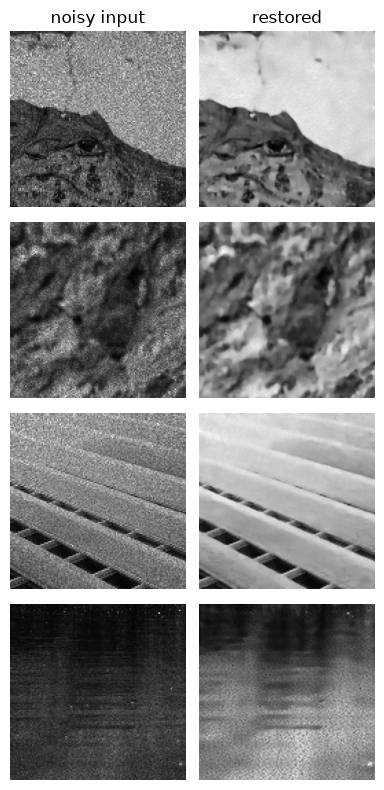

In [28]:
import matplotlib.pyplot as plt

val_step = make_val_step(normalizer_fn)

test_files = sorted(Path(TEST_LR_PATH).glob("*.npy"))[:8]
test_imgs = np.stack([np.load(f) for f in test_files])[..., None].astype(np.float32)  # (N,H,W,1)

noisy = to_device({"noisy_lr": test_imgs})["noisy_lr"]
x_norm = normalizer_fn(noisy, axis=(1, 2))
y_upsampled_test = compute_bicubic_upsample(noisy, (test_imgs.shape[1] * cfg.upsample_scale, test_imgs.shape[2] * cfg.upsample_scale))
pred, _z_d = model(x_norm, y_upsampled_test)

n = min(4, len(test_files))
fig, ax = plt.subplots(n, 2, figsize=(4, 2 * n))
for i in range(n):
    ax[i, 0].imshow(noisy[i, ..., 0], cmap="gray")
    ax[i, 1].imshow(pred[i, ..., 0], cmap="gray")
for a, t in zip(ax[0], ["noisy input", "restored"]):
    a.set_title(t)
for a in ax.flat:
    a.axis("off")
plt.tight_layout()
plt.show()

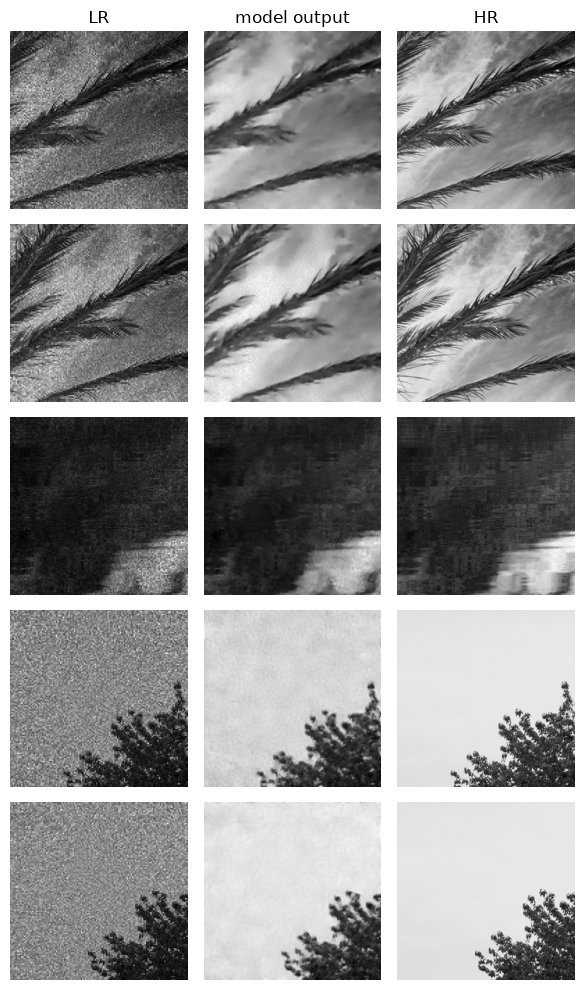

In [ ]:
lr_files = sorted(Path(TRAIN_LR_PATH).glob("*.npy"))[10:15]
gt_files = sorted(Path(TRAIN_GT_PATH).glob("*.npy"))[10:15]

lr_imgs = np.stack([np.load(f) for f in lr_files])[..., None].astype(np.float32)
hr_imgs = np.stack([np.load(f) for f in gt_files])[..., None].astype(np.float32)

lr = to_device({"noisy_lr": lr_imgs})["noisy_lr"]
hr = to_device({"gt": hr_imgs})["gt"]

x_norm = normalizer_fn(lr, axis=(1, 2))
y_upsampled = compute_bicubic_upsample(lr, hr.shape[1:3])
pred, _z_d = model(x_norm, y_upsampled)

n = len(lr_files)
fig, ax = plt.subplots(n, 3, figsize=(6, 2 * n))
for i in range(n):
    ax[i, 0].imshow(lr[i, ..., 0], cmap="gray")
    ax[i, 1].imshow(pred[i, ..., 0], cmap="gray")
    ax[i, 2].imshow(hr[i, ..., 0], cmap="gray")
for a, t in zip(ax[0], ["LR", "model output", "HR"]):
    a.set_title(t)
for a in ax.flat:
    a.axis("off")
plt.tight_layout()
plt.show()